In [1]:
from __future__ import print_function, unicode_literals, absolute_import, division
import sys
import numpy as np
import matplotlib
matplotlib.rcParams["image.interpolation"] = 'none'
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from glob import glob
from tifffile import imread
from csbdeep.utils import Path, normalize
from csbdeep.io import save_tiff_imagej_compatible

from stardist import random_label_cmap
from stardist.models import StarDist3D
import napari
np.random.seed(6)
lbl_cmap = random_label_cmap()

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: numpy.core.multiarray failed to import

In [13]:
X = sorted(glob('C:/Users/josed/Desktop/StarDIST_Training/TEST/*.tif'))
X = list(map(imread,X))

n_channel = 1 if X[0].ndim == 3 else X[0].shape[-1]
axis_norm = (0,1,2)   # normalize channels independently
# axis_norm = (0,1,2,3) # normalize channels jointly
if n_channel > 1:
    print("Normalizing image channels %s." % ('jointly' if axis_norm is None or 2 in axis_norm else 'independently'))

IndexError: list index out of range

In [4]:
basedir = r'C:\Users\josed\models'  # Specify the base directory where models/stardist/config.json exists
model = StarDist3D(None, name='stardiste', basedir=basedir)

Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.42152, nms_thresh=0.3.


In [11]:
img = normalize(X[2], 1,99.8, axis=axis_norm)
labels, details = model.predict_instances(img, n_tiles = (1,4,4))

100%|██████████████████████████████████████████████████████████████████████████████████████| 16/16 [01:38<00:00,  6.18s/it]


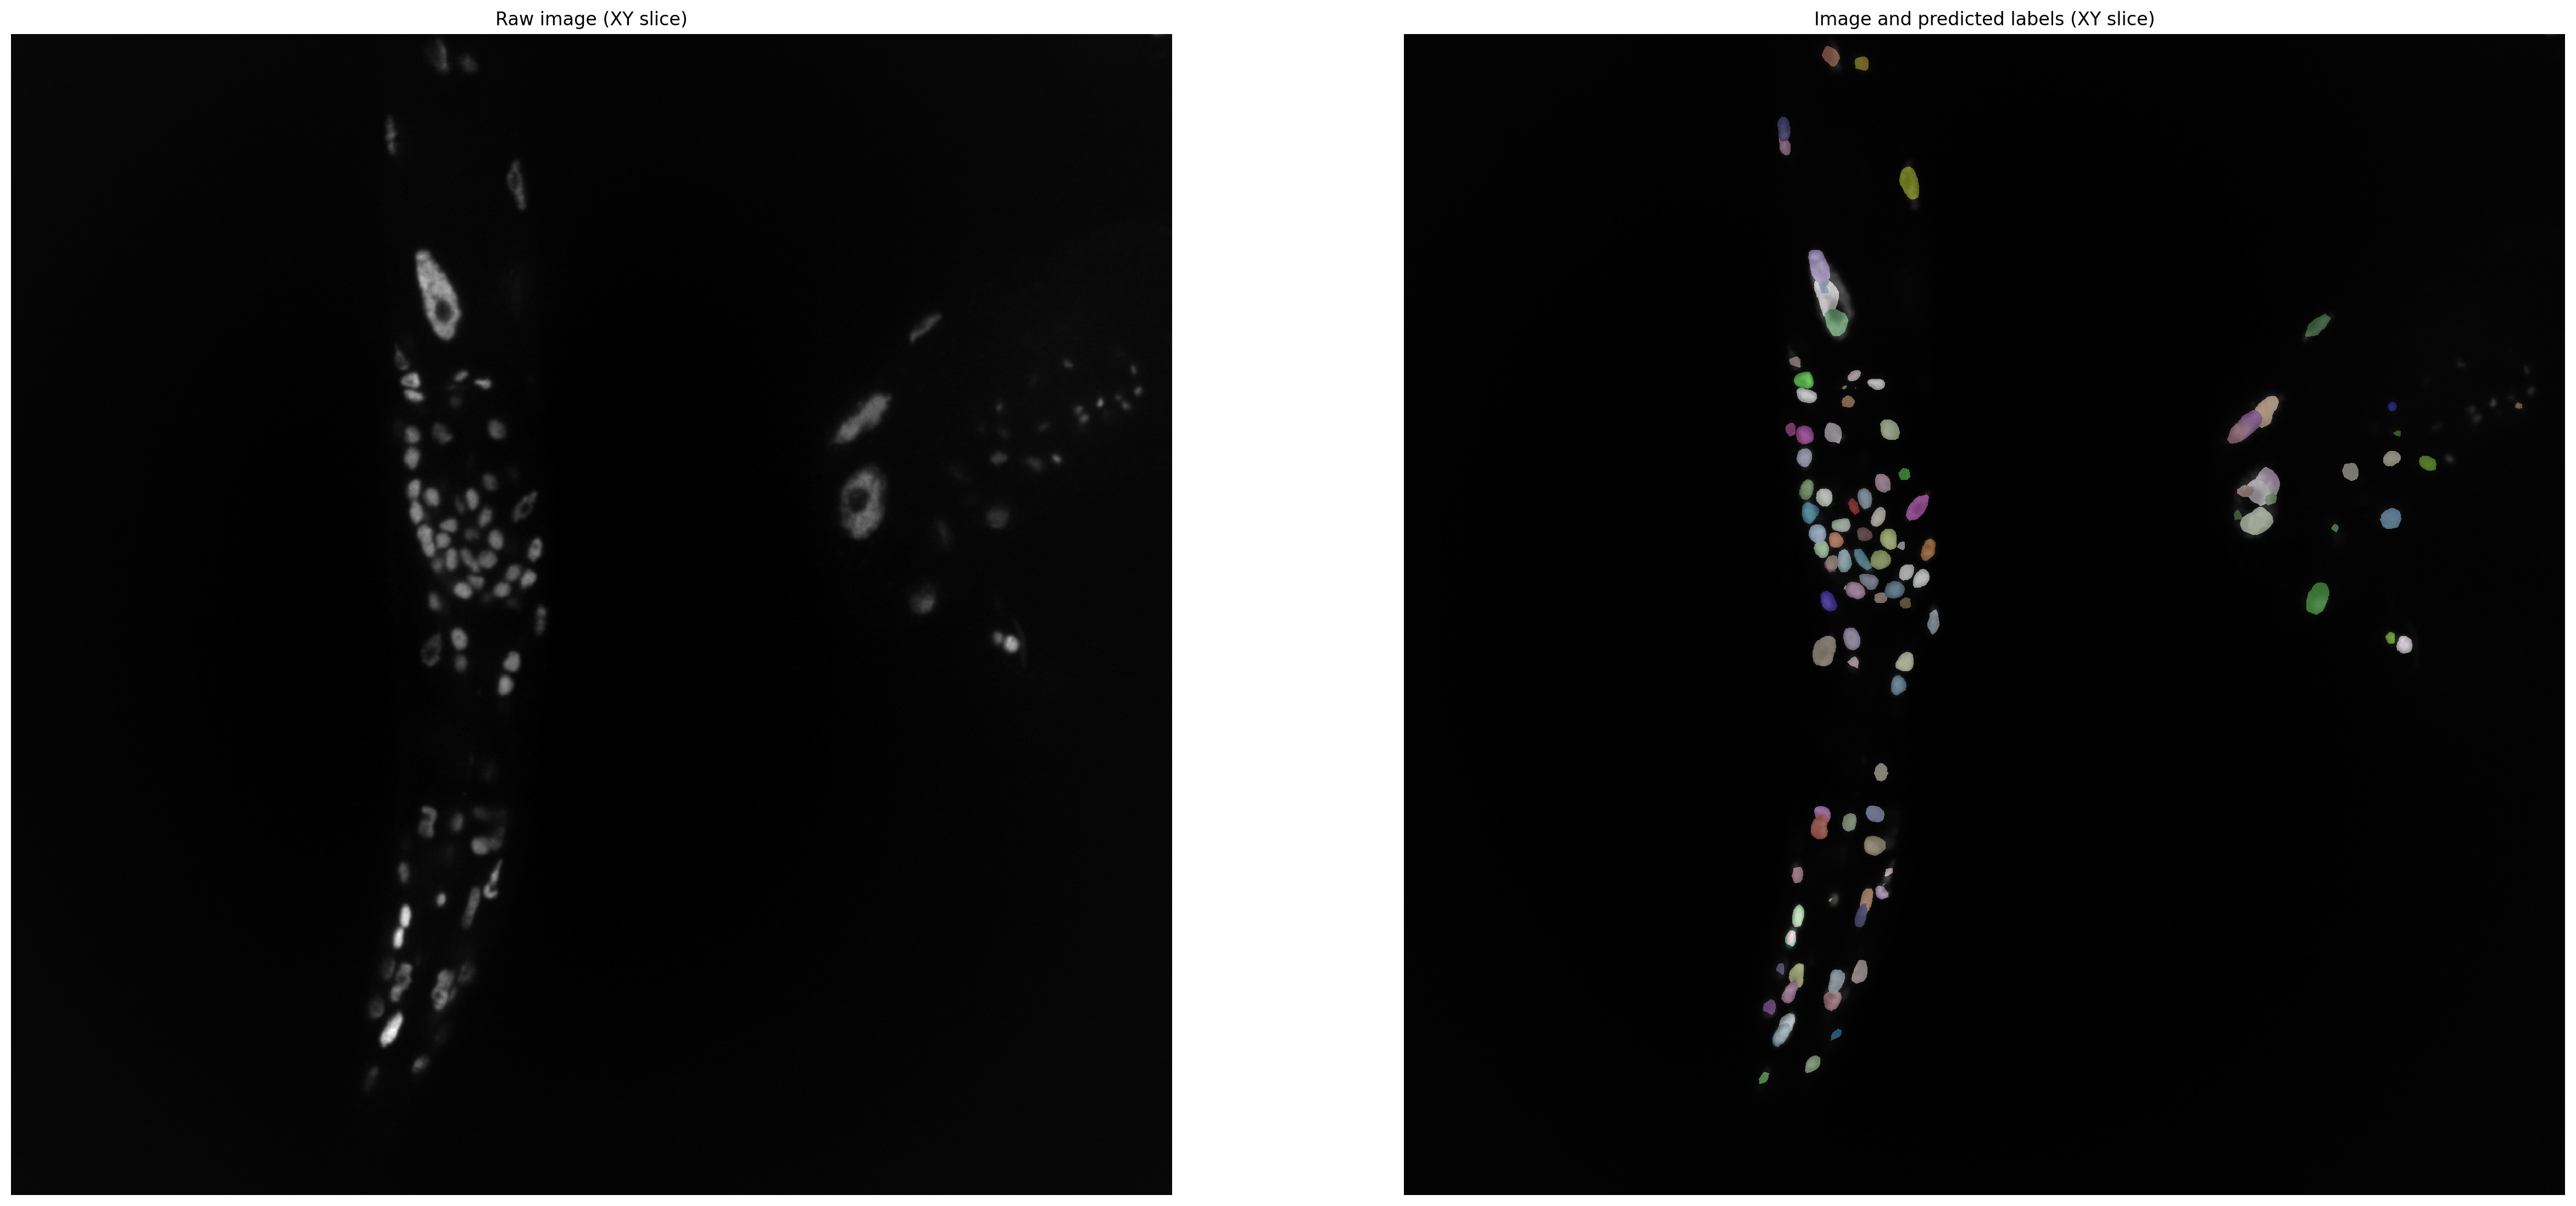

In [12]:
plt.figure(figsize=(30,20))
z = max(0, img.shape[0] // 2 - 5)
plt.subplot(121)
plt.imshow((img if img.ndim==3 else img[...,:3])[z], clim=(0,1), cmap='gray')
plt.title('Raw image (XY slice)')
plt.axis('off')
plt.subplot(122)
plt.imshow((img if img.ndim==3 else img[...,:3])[z], clim=(0,1), cmap='gray')
plt.imshow(labels[z], cmap=lbl_cmap, alpha=0.5)
plt.title('Image and predicted labels (XY slice)')
plt.axis('off');

In [8]:
viewer = napari.Viewer()

In [10]:
viewer.add_image(img, name='image')
viewer.add_labels(labels, name='labels')

<Labels layer 'labels' at 0x1d9439ba910>